# Pentameric plot for visualizing all 5 measured properties at once for the Omi32 combinatorial library in Tharp et al, 2026 (Figure 2a)

All properties are normalized on a 0,1 axis so that the full range of each property for this library can be easily visualized and the range of values for each property were manually added in Adobe Illustrator for the final publication figure

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_paths = {
    'wuhan':      '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv',
    'ba1':        '../../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv',
    'ba4':        '../../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv',
    'expression': '../../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv',
    'psr':        '../../epistasis_inference/linear_interaction_models/psr/reference-based/predicted_phenotypes/psr_raw_2order_full_biochem_predictions.csv',
}

dataframes = []

for prefix, path in file_paths.items():
    df = pd.read_csv(path, dtype={'geno': str})

    new_columns = {col: f"{prefix}_{col}" for col in df.columns if col != 'geno'}
    df.rename(columns=new_columns, inplace=True)

    print(f"Loaded {prefix}: shape {df.shape}, columns: {list(df.columns)}")
    dataframes.append(df)

merged_df = dataframes[0]

for i, df in enumerate(dataframes[1:], 1):
    merged_df = pd.merge(merged_df, df, on='geno', how='outer')
    print(f"After merging file {i+1}: shape {merged_df.shape}")

print(f"\nFinal merged shape: {merged_df.shape}")
print(f"Geno column dtype: {merged_df['geno'].dtype}")
print(f"Columns: {list(merged_df.columns)}")

Loaded wuhan: shape (8192, 3), columns: ['geno', 'wuhan_predicted_phenotype', 'wuhan_prediction_se']
Loaded ba1: shape (8192, 3), columns: ['geno', 'ba1_predicted_phenotype', 'ba1_prediction_se']
Loaded ba4: shape (8192, 3), columns: ['geno', 'ba4_predicted_phenotype', 'ba4_prediction_se']
Loaded expression: shape (8192, 3), columns: ['geno', 'expression_predicted_phenotype', 'expression_prediction_se']
Loaded psr: shape (8192, 3), columns: ['geno', 'psr_predicted_phenotype', 'psr_prediction_se']
After merging file 2: shape (8192, 5)
After merging file 3: shape (8192, 7)
After merging file 4: shape (8192, 9)
After merging file 5: shape (8192, 11)

Final merged shape: (8192, 11)
Geno column dtype: object
Columns: ['geno', 'wuhan_predicted_phenotype', 'wuhan_prediction_se', 'ba1_predicted_phenotype', 'ba1_prediction_se', 'ba4_predicted_phenotype', 'ba4_prediction_se', 'expression_predicted_phenotype', 'expression_prediction_se', 'psr_predicted_phenotype', 'psr_prediction_se']



Predicted phenotype ranges (raw values):
  wuhan_predicted_phenotype: min=5.85106, max=9.92805
  ba1_predicted_phenotype: min=6.50867, max=9.9469
  ba4_predicted_phenotype: min=6.62967, max=9.42164
  expression_predicted_phenotype: min=3.81684, max=4.42197
  psr_predicted_phenotype: min=0.929234, max=2.22912


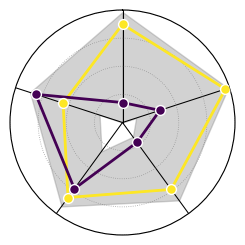

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

feature_cols = [
    "wuhan_predicted_phenotype",
    "ba1_predicted_phenotype",
    "ba4_predicted_phenotype",
    "expression_predicted_phenotype",
    "psr_predicted_phenotype",
]
geno_keys = ["1111111111111", "0000000000000"]
line_colors = ["#FDE725", "#440154"]

scale_map = {
    "wuhan_predicted_phenotype":      (6.0, 10.0),
    "ba1_predicted_phenotype":        (6.0, 10.0),
    "ba4_predicted_phenotype":        (6.0, 10.0),
    "expression_predicted_phenotype": (3.5,  4.5),
    "psr_predicted_phenotype":        (0.5,  2.5),
}

display_min = np.array([scale_map[c][0] for c in feature_cols])
display_max = np.array([scale_map[c][1] for c in feature_cols])

for c in feature_cols:
    merged_df[c] = pd.to_numeric(merged_df[c], errors="coerce")

print("\nPredicted phenotype ranges (raw values):")
for c in feature_cols:
    print(f"  {c}: min={merged_df[c].min():.6g}, max={merged_df[c].max():.6g}")


# Normalize to [0, 1] per axis (final figure in Tharp et al, 2026 shows values relative to library range for each property)
def normalize(vals, lo, hi):
    return (vals - lo) / (hi - lo)

X = merged_df[feature_cols].values
lib_min_norm = np.clip(normalize(np.nanmin(X, axis=0), display_min, display_max), 0, 1)
lib_max_norm = np.clip(normalize(np.nanmax(X, axis=0), display_min, display_max), 0, 1)

geno_vals_norm = []
for g in geno_keys:
    row = merged_df.loc[merged_df["geno"].astype(str) == str(g), feature_cols]
    if len(row) != 1:
        raise ValueError(f"Expected exactly 1 row for geno={g}, found {len(row)}")
    geno_vals_norm.append(normalize(row.values.flatten(), display_min, display_max))

# Radar geometry setup
N = len(feature_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles_closed = np.r_[angles, angles[0]]

def close(v):
    return np.r_[v, v[0]]

min_c = close(lib_min_norm)
max_c = close(lib_max_norm)
geno_c = [close(v) for v in geno_vals_norm]

# Plotting
fig = plt.figure(figsize=(2.5, 2.5))
fig.patch.set_alpha(0.0)
ax = fig.add_subplot(111, polar=True)
ax.patch.set_alpha(0.0)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_ylim(0, 1)

# Gridlines
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color='gray', alpha=0.7)
ax.xaxis.grid(True, linestyle="-", linewidth=0.75, color='black')

# Library range shading
ax.fill_between(angles_closed, min_c, max_c, color="gray", alpha=0.35, zorder=1)

ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels([])
ax.set_xticks(angles)
ax.set_xticklabels([])

# Omi32 and germline points and lines on plot
for gv, g, c in zip(geno_c, geno_keys, line_colors):
    ax.plot(angles_closed, gv, linewidth=2, color=c, zorder=10)
    ax.scatter(
        angles, gv[:-1],
        s=50, color=c,
        edgecolors="white", linewidths=1.0,
        zorder=30
    )

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.savefig(
    "Figure_2a.png",
    dpi=2000,
    bbox_inches="tight",
    transparent=True
)
plt.show()